In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 تحميل البيانات:

In [77]:
data=pd.read_csv("/content/Training.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


تنظيف البيانات:

In [78]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols] = data[cols].replace(0, np.nan)

<Axes: >

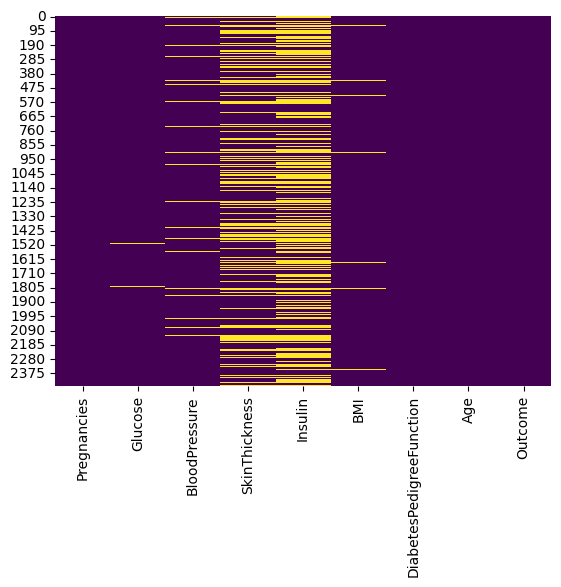

In [79]:
data.isnull().sum()
sns.heatmap(data.isnull(),cmap='viridis',cbar=False )

In [80]:
data.dtypes

,0
Pregnancies,int64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [81]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_9392/3444283585.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


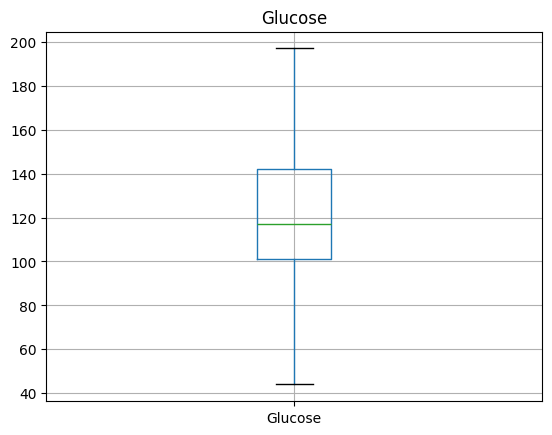

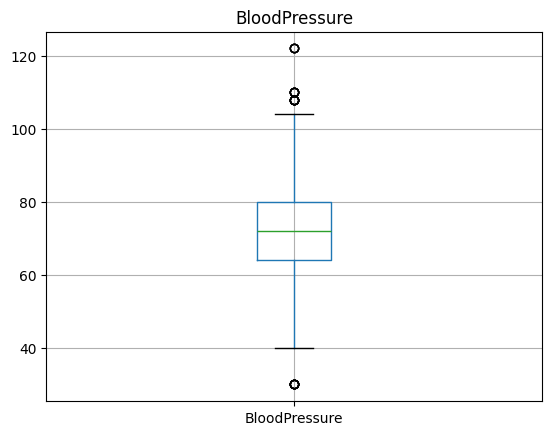

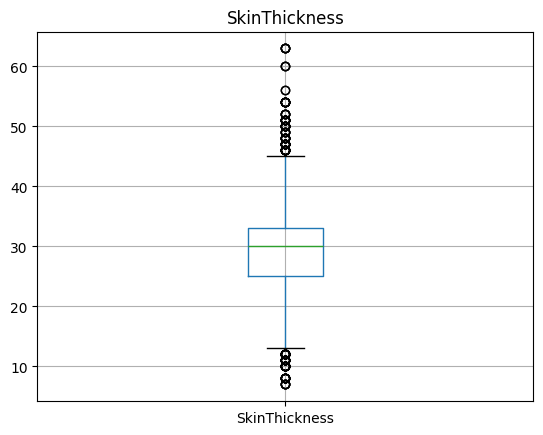

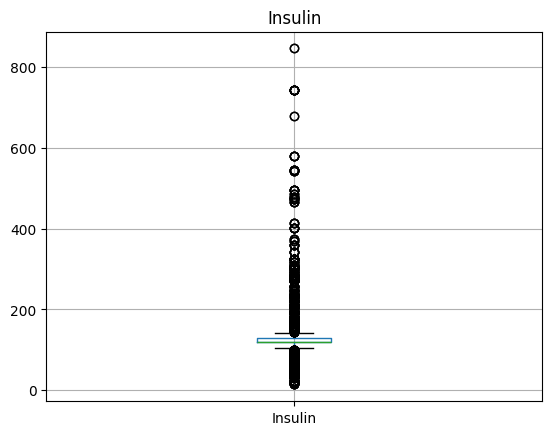

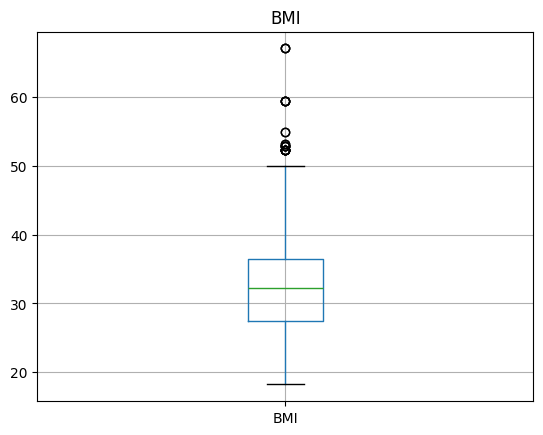

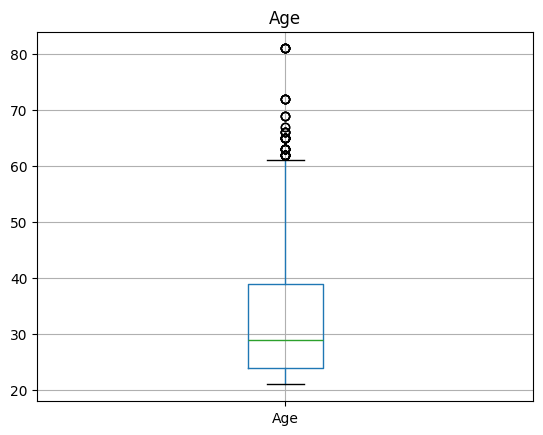

In [82]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
for col in cols:
    plt.figure()
    data.boxplot(column=col)
    plt.title(col)
    plt.show()

In [83]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col]=np.where(data[col]>upper,upper,np.where(data[col]<lower,lower,data[col]))


In [84]:
'''cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
for col in cols:
    plt.figure()
    data.boxplot(column=col)
    plt.title(col)
    plt.show()'''

"cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']\nfor col in cols:\n    plt.figure()\n    data.boxplot(column=col)\n    plt.title(col)\n    plt.show()"

استكشاف البيانات:

عرض بعض السجلات من البيانات على الشاشة؟

In [85]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,120.0,33.6,0.627,50.0,1
1,1,85.0,66.0,29.0,120.0,26.6,0.351,31.0,0
2,8,183.0,64.0,30.0,120.0,23.3,0.672,32.0,1
3,1,89.0,66.0,23.0,104.0,28.1,0.167,21.0,0
4,0,137.0,40.0,35.0,144.0,43.1,2.288,33.0,1


وصف البيانات :

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   float64
 2   BloodPressure             2460 non-null   float64
 3   SkinThickness             2460 non-null   float64
 4   Insulin                   2460 non-null   float64
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   float64
 8   Outcome                   2460 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 173.1 KB


In [87]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000
mean,3.817480,122.410569,72.227236,29.155691,121.917886,32.339004,0.491440,32.684350,0.390244
std,3.296458,30.130078,11.250195,7.945610,13.711449,6.719515,0.363917,10.820369,0.487904
min,0.000000,44.000000,40.000000,13.000000,104.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,101.000000,64.000000,25.000000,119.000000,27.400000,0.251750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,30.000000,120.000000,32.300000,0.381000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.500000,0.647000,39.000000,1.000000
max,17.000000,197.000000,104.000000,45.000000,144.000000,50.150000,2.420000,61.500000,1.000000


ما هو الوسط الحسابي و الأنحراف المعياري لأعمار الأشخاص المصابين و غير المصابين بمرض السكري من النوع الثاني  .1  

In [88]:
data.groupby('Outcome')['Age'].agg(['mean', 'std'])

,mean,std
Outcome,,
0,30.665667,10.640874
1,35.838542,10.338785


 العلاقات بين المتغيرات ضغط الدم و مؤشر كتلة الجسم . 2   
 BloodPressure .vs. BMI

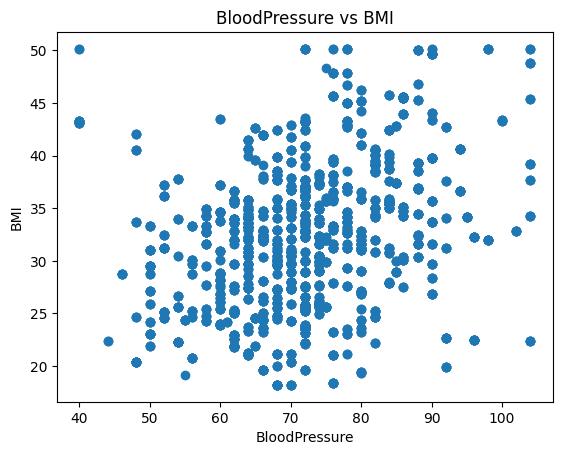

In [89]:
plt.scatter(data['BloodPressure'], data['BMI'])
plt.xlabel('BloodPressure')
plt.ylabel('BMI')
plt.title('BloodPressure vs BMI')
plt.show()

العلاقات بين مستوى الجلوكوز في الدم و مستوى الأنسولين في الدم . 3
Glucose .vs. Insulin

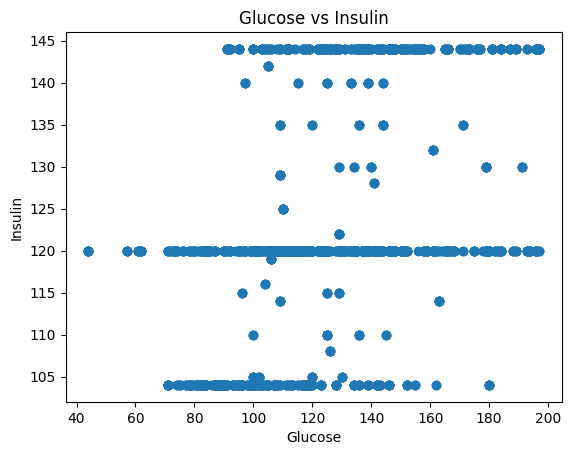

In [90]:
plt.scatter(data['Glucose'], data['Insulin'])
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.title('Glucose vs Insulin')
plt.show()

حساب معدل الأرتباط بين كل متغيرين و ترتيبهم من الأعلى الى الأقل  :

In [91]:
corr = data.corr()
corr.unstack().sort_values(ascending=False)

Pregnancies               Pregnancies                 1.000000
Glucose                   Glucose                     1.000000
DiabetesPedigreeFunction  DiabetesPedigreeFunction    1.000000
Outcome                   Outcome                     1.000000
Age                       Age                         1.000000
                                                        ...   
DiabetesPedigreeFunction  Age                         0.042773
                          BloodPressure              -0.036940
BloodPressure             DiabetesPedigreeFunction   -0.036940
Pregnancies               DiabetesPedigreeFunction   -0.053568
DiabetesPedigreeFunction  Pregnancies                -0.053568
Length: 81, dtype: float64

1.  ما هو متوسط مستوى الأنسولين في الدم للنساء الحوامل التي تتجاوز أعمارهم سن 35؟


In [92]:
data[(data['Age'] > 35) & (data['Pregnancies'] > 0)]['Insulin'].mean()

np.float64(124.22670025188917)

2. ما هو أقل مؤشر كتلة الجسم للرجال المصابين بالسكري من النوع الثاني؟

In [93]:
data[data['Outcome'] == 1]['BMI'].min()

22.9

3. ما هو أقل و أعلى قياس ضغط الدم للنساء الغير مصابات بالسكري؟


In [94]:
subset = data[(data['Outcome'] == 0) & (data['Pregnancies'] > 0)]

print(subset['BloodPressure'].min())
print(subset['BloodPressure'].max())

40.0
104.0


4. ما هو أقل و أعلى قياس ضغط الدم للرجال التي أعمارهم فوق 40؟


In [95]:
subset = data[(data['Age'] > 40) & (data['Pregnancies'] == 0)]

subset['BloodPressure'].min()
subset['BloodPressure'].max()

104.0

أستخدم رسوم Boxplot  ل هل تزداد احتمالية الإصابة بمرض السكري مع تقدم العمر؟

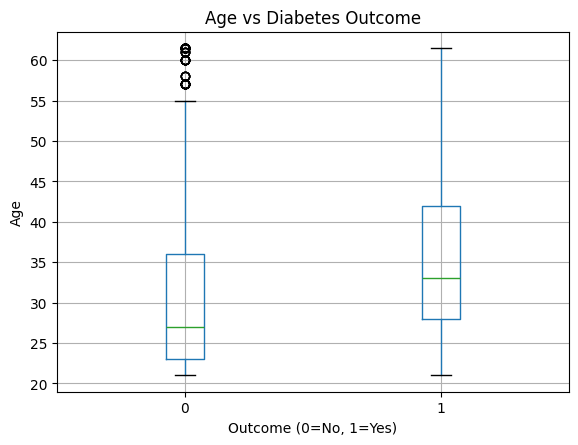

In [96]:
data.boxplot(column='Age', by='Outcome')
plt.title('Age vs Diabetes Outcome')
plt.suptitle('')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()

نلاحظ : الأشخاص المصابين بالسكري أعمارهم أكبر بشكل عام

2. أستخدم رسوم Barchart ل هل تزداد احتمالية الإصابة بمرض السكري عند الرجال أكثر من النساء؟ و ما علاقة ذلك بمؤشر كتلة الجسم؟


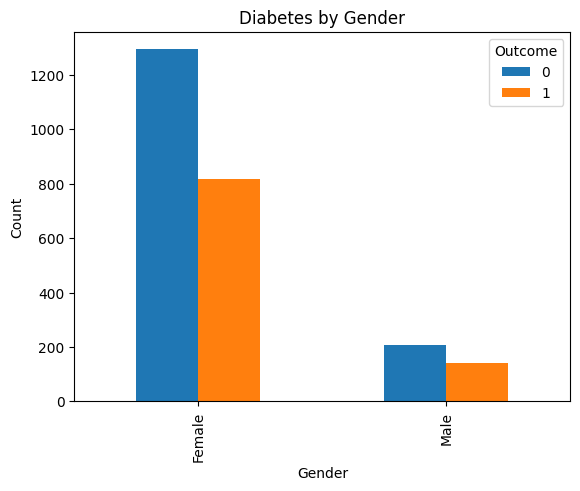

In [97]:
data['Gender'] = data['Pregnancies'].apply(lambda x: 'Female' if x > 0 else 'Male')

import matplotlib.pyplot as plt

counts = data.groupby(['Gender', 'Outcome']).size().unstack()

counts.plot(kind='bar')
plt.title('Diabetes by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

نلاحظ من الرسم : عدد حالات الإصابة بمرض السكري أعلى بين الإناث مقارنة بالذكور

علاقة BMI:

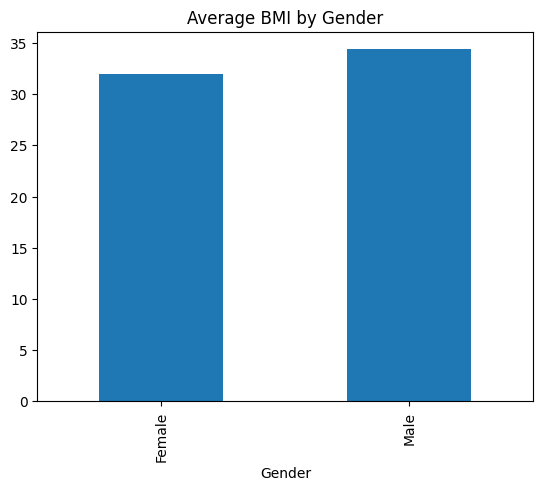

In [98]:
data.groupby('Gender')['BMI'].mean().plot(kind='bar')
plt.title('Average BMI by Gender')
plt.show()

3. استخدم الرسوم الخطية للأستفسار عن نوعية العلاقة بين مؤشر كتلة الجسم و مستوى الجلوكوز في الدم.

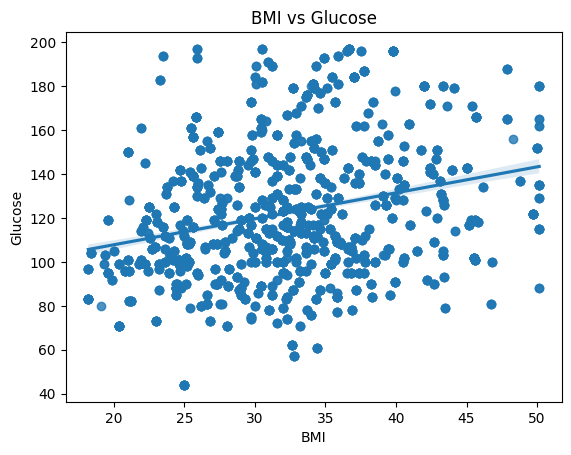

In [99]:
sns.regplot(x='BMI', y='Glucose', data=data)
plt.title('BMI vs Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show()

وجود علاقة طردية بين مؤشر كتلة الجسم ومستوى الجلوكوز في الدم، حيث يظهر خط الاتجاه ميلًا للأعلى،